# Speech Emotion Recognition (SER) Stacking Ensemble Pipeline

This notebook implements the complete training and evaluation pipeline for our **Stacking Ensemble Classifier** (combining **XGBoost**, **LightGBM**, and **CatBoost** using an **Extra Trees meta-classifier**).

### Key Features:
1. **Full Feature Set**: Dynamically loads and utilizes all **48 features** from the dataset.
2. **Out-of-Fold (OOF) Prediction Generation**: Uses a 3-Fold Stratified Cross-Validation on the training set to prevent data leakage during meta-model training.
3. **Stacking Classifier**: Trains an Extra Trees classifier on base models' probability predictions, learning how to combine their strengths.
4. **GPU/CPU Automatic Detection**: Auto-detects CUDA/GPU availability to run calculations efficiently.
5. **Rich Visualizations**: Generates inline side-by-side confusion matrices, model comparison plots, and per-class performance breakdowns.
6. **Deployment Serialization**: Saves the trained models, scaler, label encoder, and text results report directly to disk.


In [1]:
# ============================================================
# Library Imports
# ============================================================
import json
import os
import warnings
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost -q
    import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    %pip install lightgbm -q
    import lightgbm as lgb

try:
    from catboost import CatBoostClassifier
except ImportError:
    %pip install catboost -q
    from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
import torch

warnings.filterwarnings("ignore")


In [2]:
# ============================================================
# Global Constants & GPU Support Check
# ============================================================
RANDOM_STATE = 42

# Check if CUDA/GPU support is available
CUDA_AVAILABLE = torch.cuda.is_available()
print("CUDA Available (PyTorch):", CUDA_AVAILABLE)


CUDA Available (PyTorch): False


## Dataset Path Configuration

We resolve the location of the `all_emotions.csv` dataset, using a robust path fallback that checks both the `dataset/` subdirectory and the repository root.


In [3]:
# ============================================================
# Path Configuration
# ============================================================
_base = os.getcwd()
_project_root = os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
ALL_EMOTIONS_CSV = os.path.normpath(os.path.join(_project_root, "dataset", "all_emotions.csv"))
if not os.path.isfile(ALL_EMOTIONS_CSV):
    fallback_csv = os.path.normpath(os.path.join(_project_root, "all_emotions.csv"))
    if os.path.isfile(fallback_csv):
        ALL_EMOTIONS_CSV = fallback_csv

print("Dataset path:", ALL_EMOTIONS_CSV)
print("File exists:", os.path.isfile(ALL_EMOTIONS_CSV))


Dataset path: c:\Users\User\Downloads\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\dataset\all_emotions.csv
File exists: True


## Data Loading, Imputation & Feature Extraction

We load the CSV file, clean null targets, and dynamically extract **all available feature columns** (excluding the target labels column). Missing values are handled using median imputation.


In [4]:
# ============================================================
# Data Loading and Exploration
# ============================================================
df = pd.read_csv(ALL_EMOTIONS_CSV)
target_col = "label" if "label" in df.columns else "Label"

# Clean missing label rows
df_cleaned = df.dropna(subset=[target_col]).copy()
df_cleaned = df_cleaned[df_cleaned[target_col].astype(str).str.strip().str.lower() != "nan"]

# Extract all columns except the target label as features (48 features)
FEATURE_COLS = [col for col in df_cleaned.columns if col not in [target_col]]
print(f"Number of features selected dynamically: {len(FEATURE_COLS)}")

# Feature Imputation
for col in FEATURE_COLS:
    s = pd.to_numeric(df_cleaned[col], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    df_cleaned[col] = s.fillna(med)

X = df_cleaned[FEATURE_COLS].values
y_label = df_cleaned[target_col].astype(str).str.strip().values

# Label encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_label)

print(f"Cleaned X shape: {X.shape}")
print(f"Classes: {encoder.classes_}")


Number of features selected dynamically: 48
Cleaned X shape: (54485, 48)
Classes: ['anger' 'disgust' 'fear' 'happy' 'neutral' 'sad']


## Train-Test Splitting & Scaling

We split the dataset into stratified training (80%) and testing (20%) sets to ensure proportional label distribution, and perform standard scaling on feature matrices.


In [5]:
# ============================================================
# Stratified Train-Test Split and Standard Scaling
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")


Train Shape: (43588, 48) | Test Shape: (10897, 48)


## Model Instantiation with Best Hyperparameters

We load or define the optimized hyperparameters for XGBoost, LightGBM, and CatBoost. The model constructor dynamically configures GPU/CPU run options based on hardware availability.


In [6]:
# ============================================================
# Model Instantiation
# ============================================================
# Try to load best parameters if they exist, otherwise use optimized defaults
params_path = os.path.join(_project_root, "best_params.json")
best_params = {}
if os.path.isfile(params_path):
    try:
        with open(params_path, "r") as f:
            best_params = json.load(f)
        print("Loaded best_params.json successfully.")
    except Exception as e:
        print("Error loading best_params.json:", e)

xgb_params = best_params.get("xgboost", {
    "n_estimators": 468,
    "max_depth": 10,
    "learning_rate": 0.17549140891728818,
    "subsample": 0.9690394070981359,
    "colsample_bytree": 0.7725519831966194,
    "gamma": 1.0492767129301485e-08,
})
xgb_model = xgb.XGBClassifier(
    **xgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    device="cuda" if CUDA_AVAILABLE else "cpu",
)

lgb_params = best_params.get("lightgbm", {
    "n_estimators": 499,
    "max_depth": 11,
    "num_leaves": 67,
    "learning_rate": 0.24625126683753454,
    "subsample": 0.6909971314141472,
    "colsample_bytree": 0.7554088091076056,
})
lgb_model = lgb.LGBMClassifier(
    **lgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    objective="multiclass",
    num_class=len(encoder.classes_),
    device="gpu" if CUDA_AVAILABLE else "cpu",
)

cb_params = best_params.get("catboost", {
    "iterations": 500,
    "depth": 8,
    "learning_rate": 0.15,
    "l2_leaf_reg": 3.0,
})
cb_model = CatBoostClassifier(
    **cb_params,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
    task_type="GPU" if CUDA_AVAILABLE else "CPU",
)

print("Models instantiated successfully.")


Loaded best_params.json successfully.
Models instantiated successfully.


## Out-of-Fold (OOF) Prediction Generation

To build our Stacking Ensemble without leaking target labels, we perform a 3-Fold Stratified Cross-Validation on the training set to get validation probability predictions (OOF predictions).

In [7]:
# ============================================================
# Out-of-Fold Predictions
# ============================================================
print("Training Out-Of-Fold models for stacking meta-model training...")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
xgb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))
lgb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))
cb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    print(f"  Processing Fold {fold + 1}...")
    X_tr, y_tr = X_train_scaled[train_idx], y_train[train_idx]
    X_va, y_va = X_train_scaled[val_idx], y_train[val_idx]

    # Instantiate fold models
    xgb_m = xgb.XGBClassifier(
        **xgb_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="mlogloss",
        objective="multi:softprob",
        num_class=len(encoder.classes_),
        device="cuda" if CUDA_AVAILABLE else "cpu",
    )
    lgb_m = lgb.LGBMClassifier(
        **lgb_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        objective="multiclass",
        num_class=len(encoder.classes_),
        device="gpu" if CUDA_AVAILABLE else "cpu",
    )
    cb_m = CatBoostClassifier(
        **cb_params,
        loss_function="MultiClass",
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        task_type="GPU" if CUDA_AVAILABLE else "CPU",
)

    # Fit and predict probabilities
    xgb_m.fit(X_tr, y_tr)
    lgb_m.fit(X_tr, y_tr)
    cb_m.fit(X_tr, y_tr)

    xgb_oof[val_idx] = xgb_m.predict_proba(X_va)
    lgb_oof[val_idx] = lgb_m.predict_proba(X_va)
    cb_oof[val_idx] = cb_m.predict_proba(X_va)

print("OOF predictions generated successfully.")


Training Out-Of-Fold models for stacking meta-model training...
  Processing Fold 1...
  Processing Fold 2...
  Processing Fold 3...
OOF predictions generated successfully.


## Training Stacking Meta-Classifier

We concatenate the base models' OOF prediction probabilities to build meta-features, and train an Extra Trees classifier as the stacking meta-learner.

In [8]:
# ============================================================
# Stacking Meta-Model Training
# ============================================================
print("Training Stacking Meta-Classifier (Extra Trees)...")
oof_meta_features = np.hstack([xgb_oof, lgb_oof, cb_oof])

meta_model = ExtraTreesClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1)
meta_model.fit(oof_meta_features, y_train)

print("Stacking Meta-Classifier trained successfully.")


Training Stacking Meta-Classifier (Extra Trees)...
Stacking Meta-Classifier trained successfully.


## Final Model Training on Full Training Set

We train the base models one final time on the entire 80% training set. We generate probability predictions on the unseen 20% test set, feed them to the meta-model, and compute predictions.

In [9]:
# ============================================================
# Final Training & Test Prediction
# ============================================================
print("Fitting final models on full scaled training set...")
xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)
cb_model.fit(X_train_scaled, y_train)

# Generate test set base probabilities
xgb_proba = xgb_model.predict_proba(X_test_scaled)
lgb_proba = lgb_model.predict_proba(X_test_scaled)
cb_proba = cb_model.predict_proba(X_test_scaled)

# Concat test meta-features
test_meta_features = np.hstack([xgb_proba, lgb_proba, cb_proba])

# Run meta-classifier predictions
ensemble_pred = meta_model.predict(test_meta_features)

# Base models predictions for comparison
xgb_pred = np.argmax(xgb_proba, axis=1)
lgb_pred = np.argmax(lgb_proba, axis=1)
cb_pred = np.argmax(cb_proba, axis=1)

print("Final predictions computed.")


Fitting final models on full scaled training set...
Final predictions computed.


## Performance Evaluation: Classification Reports

We evaluate and print classification reports for all models.

In [10]:
# ============================================================
# Model Performance Evaluation
# ============================================================
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")
xgb_kappa = cohen_kappa_score(y_test, xgb_pred)

lgb_f1 = f1_score(y_test, lgb_pred, average="weighted")
lgb_kappa = cohen_kappa_score(y_test, lgb_pred)

cb_f1 = f1_score(y_test, cb_pred, average="weighted")
cb_kappa = cohen_kappa_score(y_test, cb_pred)

ensemble_f1 = f1_score(y_test, ensemble_pred, average="weighted")
ensemble_kappa = cohen_kappa_score(y_test, ensemble_pred)
ensemble_report = classification_report(y_test, ensemble_pred, target_names=encoder.classes_, output_dict=True)

print("\n=== XGBoost Test Metrics ===")
print(classification_report(y_test, xgb_pred, target_names=encoder.classes_))

print("\n=== LightGBM Test Metrics ===")
print(classification_report(y_test, lgb_pred, target_names=encoder.classes_))

print("\n=== CatBoost Test Metrics ===")
print(classification_report(y_test, cb_pred, target_names=encoder.classes_))

print("\n=== Stacking Ensemble (XGB + LGB + CB -> Extra Trees) ===")
print(classification_report(y_test, ensemble_pred, target_names=encoder.classes_))



=== XGBoost Test Metrics ===
              precision    recall  f1-score   support

       anger       0.94      0.91      0.93      1863
     disgust       0.84      0.87      0.86      1863
        fear       0.87      0.85      0.86      1863
       happy       0.83      0.86      0.85      1863
     neutral       0.80      0.83      0.81      1583
         sad       0.88      0.86      0.87      1862

    accuracy                           0.86     10897
   macro avg       0.86      0.86      0.86     10897
weighted avg       0.86      0.86      0.86     10897


=== LightGBM Test Metrics ===
              precision    recall  f1-score   support

       anger       0.95      0.91      0.93      1863
     disgust       0.85      0.88      0.86      1863
        fear       0.87      0.87      0.87      1863
       happy       0.85      0.86      0.86      1863
     neutral       0.81      0.84      0.82      1583
         sad       0.88      0.86      0.87      1862

    accuracy    

## Confusion Matrices Visualizations

We plot and display confusion matrices side-by-side.

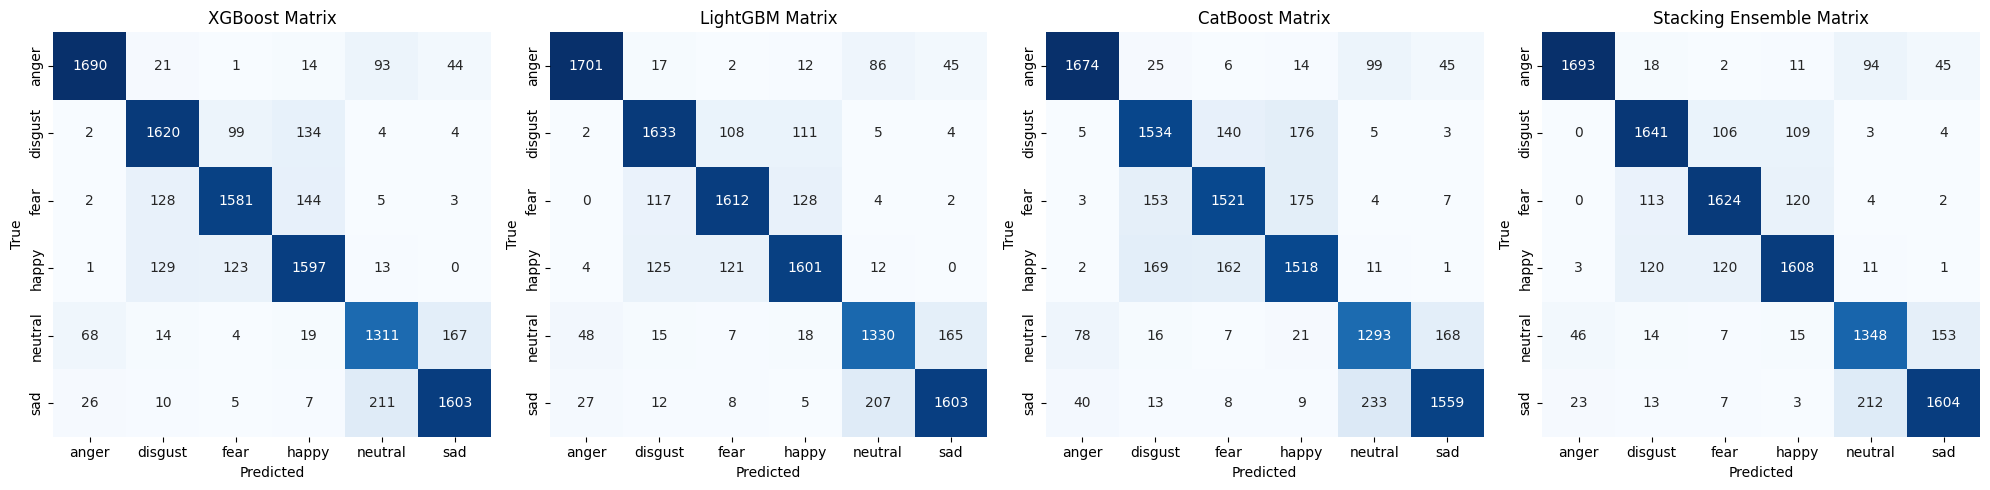

In [11]:
# ============================================================
# Confusion Matrices Visualizations
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

predictions = [
    (xgb_pred, "XGBoost Matrix"),
    (lgb_pred, "LightGBM Matrix"),
    (cb_pred, "CatBoost Matrix"),
    (ensemble_pred, "Stacking Ensemble Matrix")
]

for idx, (pred, title) in enumerate(predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=axes[idx], cbar=False)
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
figures_dir = os.path.join(_project_root, "figures")
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, "stacking_confusion.png"), dpi=200, bbox_inches="tight")
plt.show()


## Performance Comparison: F1 and Cohen Kappa

We compare the weighted F1-score and Cohen Kappa of all models.

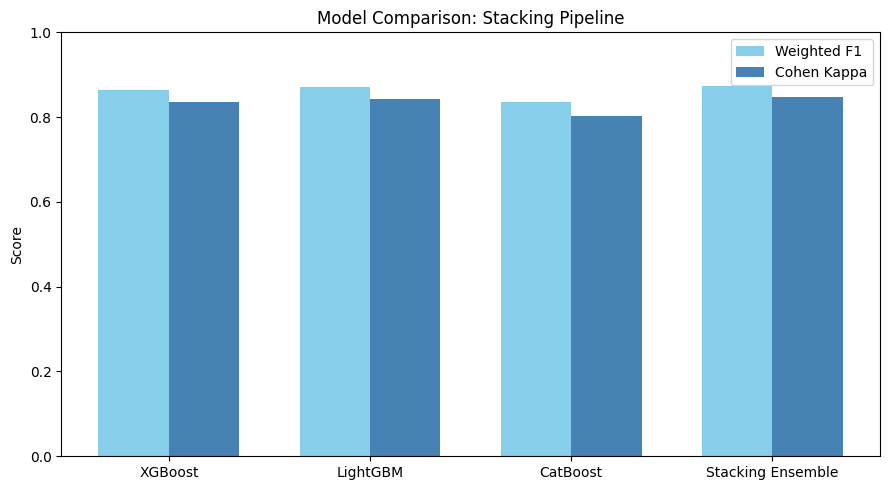

In [12]:
# ============================================================
# Performance Comparison Chart
# ============================================================
models = ["XGBoost", "LightGBM", "CatBoost", "Stacking Ensemble"]
f1_scores = [xgb_f1, lgb_f1, cb_f1, ensemble_f1]
kappas = [xgb_kappa, lgb_kappa, cb_kappa, ensemble_kappa]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, f1_scores, width, label="Weighted F1", color="skyblue")
plt.bar(x + width / 2, kappas, width, label="Cohen Kappa", color="steelblue")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison: Stacking Pipeline")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "stacking_model_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()


## Per-Class F1-Scores

We analyze the per-class F1 performance of the Stacking Ensemble.

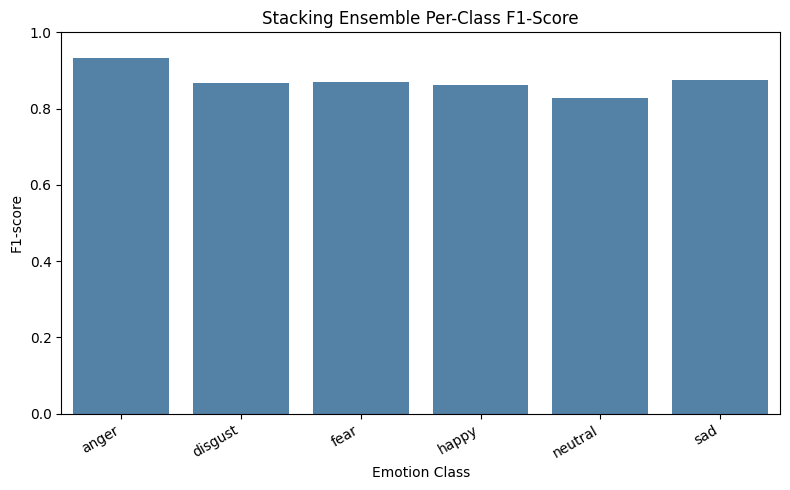

In [13]:
# ============================================================
# Stacking Ensemble Per-Class F1-Scores
# ============================================================
class_f1 = [ensemble_report[label]["f1-score"] for label in encoder.classes_]

plt.figure(figsize=(8, 5))
sns.barplot(x=list(encoder.classes_), y=class_f1, color="steelblue")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Emotion Class")
plt.title("Stacking Ensemble Per-Class F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "stacking_class_f1.png"), dpi=200, bbox_inches="tight")
plt.show()


## Summary & Artifact Serialization

Final comparative metrics output and serialization of production assets.

In [14]:
# ============================================================
# Summary Report Table & Artifact Serialization
# ============================================================
print("\n=== Model Metrics Summary ===")
print(f"XGBoost           | Weighted F1: {xgb_f1:.4f} | Cohen's Kappa: {xgb_kappa:.4f}")
print(f"LightGBM          | Weighted F1: {lgb_f1:.4f} | Cohen's Kappa: {lgb_kappa:.4f}")
print(f"CatBoost          | Weighted F1: {cb_f1:.4f} | Cohen's Kappa: {cb_kappa:.4f}")
print(f"Stacking Ensemble | Weighted F1: {ensemble_f1:.4f} | Cohen's Kappa: {ensemble_kappa:.4f}")

# Save trained models and preprocessors to disk
print("\nSerializing production artifacts for live backend...")
joblib.dump(xgb_model, 'ser_xgb_model.joblib')
joblib.dump(lgb_model, 'ser_lgb_model.joblib')
joblib.dump(cb_model,  'ser_cb_model.joblib')
joblib.dump(meta_model, 'ser_meta_model.joblib')
joblib.dump(scaler,    'ser_ensemble_scaler.joblib')
joblib.dump(encoder,   'ser_ensemble_encoder.joblib')
print("SUCCESS: Models, scaler, encoder, and stacking meta-classifier saved to disk!")

# Save classification report to file
with open('stacking_report.txt', 'w') as f:
    f.write('=== Speech Emotion Recognition Stacking Ensemble Training Report ===\n\n')
    f.write('=== XGBoost Weighted F1 ===\n')
    f.write(f'{xgb_f1:.4f}\n\n')
    f.write('=== LightGBM Weighted F1 ===\n')
    f.write(f'{lgb_f1:.4f}\n\n')
    f.write('=== CatBoost Weighted F1 ===\n')
    f.write(f'{cb_f1:.4f}\n\n')
    f.write('=== Stacking Ensemble (XGB + LGB + CB -> Extra Trees) ===\n')
    f.write(classification_report(y_test, ensemble_pred, target_names=encoder.classes_))
    f.write(f'\nEnsemble Weighted F1: {ensemble_f1:.4f}\n')
    f.write(f'Ensemble Cohen Kappa: {ensemble_kappa:.4f}\n')
print('Saved performance report to stacking_report.txt')



=== Model Metrics Summary ===
XGBoost           | Weighted F1: 0.8632 | Cohen's Kappa: 0.8353
LightGBM          | Weighted F1: 0.8704 | Cohen's Kappa: 0.8439
CatBoost          | Weighted F1: 0.8355 | Cohen's Kappa: 0.8019
Stacking Ensemble | Weighted F1: 0.8739 | Cohen's Kappa: 0.8481

Serializing production artifacts for live backend...
SUCCESS: Models, scaler, encoder, and stacking meta-classifier saved to disk!
Saved performance report to stacking_report.txt
